# Cross-Version Benchmark Leaderboards

This notebook builds leaderboards from benchmark outputs in `benchmarking/benchmarks/*/results/baseline` and `v10+`.

When present, `baseline` is the CLIP-only ablation (no caption generation, keyword search, or hybrid search).

It includes:
- Primary leaderboard (`MRR`, `Success@25`)
- Primary + Diversity leaderboard (adds `Diversity@25`)

`Success@25` is computed from the `hit` column mean.


A separate **Primary leaderboard (with ablation studies)** section includes `ablation_*` runs alongside baseline and `v10+`.


In [1]:
import sys
from pathlib import Path
from IPython.display import display

# Repo root from benchmarking/benchmarks/<BENCHMARK>/results
_repo_root = Path.cwd().parents[3]
sys.path.insert(0, str(_repo_root))

base_path = (_repo_root / "benchmarking" / "benchmarks").resolve()

from benchmarking.helpers.plot import (
    render_single_benchmark_leaderboard,
    DEFAULT_PRIMARY_WEIGHTS,
    DEFAULT_PRIMARY_PLUS_DIVERSITY_WEIGHTS,
)

In [2]:
# Configuration
# This notebook ranks only the benchmark folder it lives in.
# Expected cwd when running this notebook: benchmarking/benchmarks/<BENCHMARK>/results
current_benchmark = Path.cwd().parents[0].name if Path.cwd().name == "results" else Path.cwd().name
min_version = 10

# Default metric weights are equal, but can be customized.
primary_metric_weights = dict(DEFAULT_PRIMARY_WEIGHTS)
primary_plus_diversity_metric_weights = dict(DEFAULT_PRIMARY_PLUS_DIVERSITY_WEIGHTS)

print("Base path:", base_path)
print("Benchmark selected:", current_benchmark)
print("Primary weights:", primary_metric_weights)
print("Primary + Diversity weights:", primary_plus_diversity_metric_weights)

Base path: /home/runner/work/sage-nrp-image-search/sage-nrp-image-search/benchmarking/benchmarks
Benchmark selected: INQUIRE
Primary weights: {'MRR': 0.5, 'Success@25': 0.5}
Primary + Diversity weights: {'MRR': 0.3333333333333333, 'Success@25': 0.3333333333333333, 'Diversity@25': 0.3333333333333333}


## Primary Leaderboard

Ranking uses weighted composite of:
- `MRR`
- `Success@25`


INQUIRE (Primary):


,benchmark,system_version,query_count,MRR,Success@25,Precision@25,NDCG@25,Recall@25,Diversity@25,composite_score,rank_within_benchmark
0,INQUIRE,v10,160,0.591846,0.96250,0.228125,0.642270,0.626355,0.214108,0.777173,1
1,INQUIRE,v11,160,0.613772,0.93750,0.231500,0.655968,0.634187,0.216362,0.775636,2
2,INQUIRE,v13,160,0.683033,0.85000,0.158250,0.694929,0.453076,0.281148,0.766516,3
3,INQUIRE,v12,160,0.593178,0.93750,0.234500,0.661800,0.643656,0.217910,0.765339,4
4,INQUIRE,v14,160,0.636381,0.85000,0.164000,0.680001,0.443184,0.279481,0.743191,5
5,INQUIRE,v15,160,0.631580,0.84375,0.165500,0.682703,0.443309,0.276164,0.737665,6
6,INQUIRE,baseline,160,0.449432,0.95000,0.190000,0.556234,0.524803,0.176464,0.699716,7


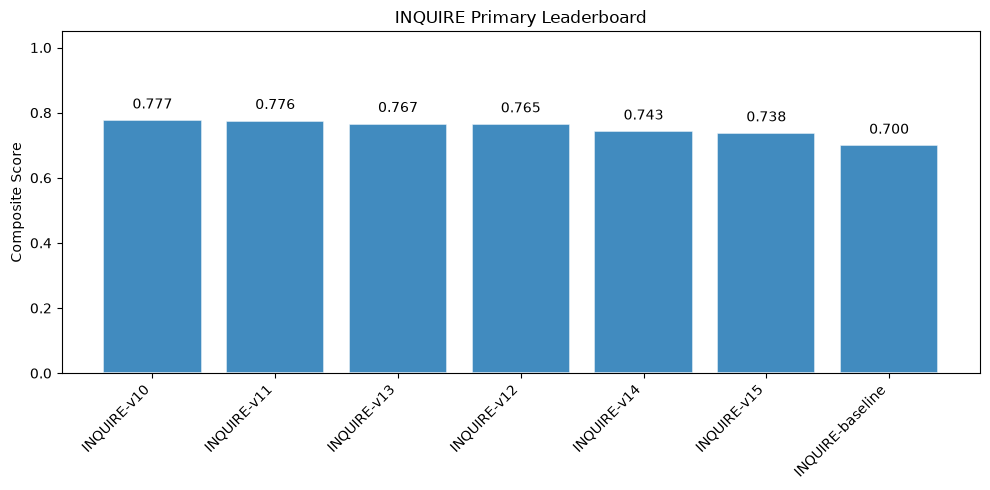

In [3]:
primary_df = render_single_benchmark_leaderboard(
    base_path=base_path,
    benchmark=current_benchmark,
    min_version=min_version,
    mode="primary",
    metric_weights=primary_metric_weights,
    display_fn=display,
)

## Primary + Diversity Leaderboard

Adds `Diversity@25` to the weighted score.


INQUIRE (Primary + Diversity):


,benchmark,system_version,query_count,MRR,Success@25,Precision@25,NDCG@25,Recall@25,Diversity@25,composite_score,rank_within_benchmark
0,INQUIRE,v13,160,0.683033,0.85000,0.158250,0.694929,0.453076,0.281148,0.604727,1
1,INQUIRE,v10,160,0.591846,0.96250,0.228125,0.642270,0.626355,0.214108,0.589484,2
2,INQUIRE,v11,160,0.613772,0.93750,0.231500,0.655968,0.634187,0.216362,0.589211,3
3,INQUIRE,v14,160,0.636381,0.85000,0.164000,0.680001,0.443184,0.279481,0.588621,4
4,INQUIRE,v15,160,0.631580,0.84375,0.165500,0.682703,0.443309,0.276164,0.583832,5
5,INQUIRE,v12,160,0.593178,0.93750,0.234500,0.661800,0.643656,0.217910,0.582862,6
6,INQUIRE,baseline,160,0.449432,0.95000,0.190000,0.556234,0.524803,0.176464,0.525299,7


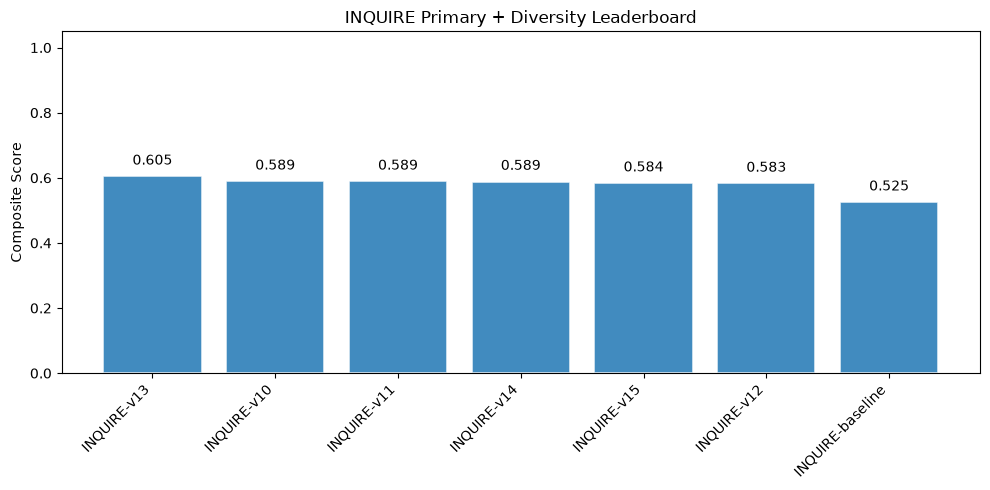

In [4]:
primary_plus_diversity_df = render_single_benchmark_leaderboard(
    base_path=base_path,
    benchmark=current_benchmark,
    min_version=min_version,
    mode="primary_plus_diversity",
    metric_weights=primary_plus_diversity_metric_weights,
    display_fn=display,
)

## Primary Leaderboard (with Ablation Studies)

Same weighted composite as the primary leaderboard (`MRR`, `Success@25`), but also includes `ablation_*` result folders when present.



INQUIRE (Primary (with Ablation Studies)):


,benchmark,system_version,query_count,MRR,Success@25,Precision@25,NDCG@25,Recall@25,Diversity@25,composite_score,rank_within_benchmark
0,INQUIRE,ablation_vec_only,160,0.621321,0.98750,0.249500,0.674289,0.709272,0.185277,0.804410,1
1,INQUIRE,ablation_img_only,160,0.583886,0.98125,0.253500,0.567077,0.703313,0.196284,0.782568,2
2,INQUIRE,v10,160,0.591846,0.96250,0.228125,0.642270,0.626355,0.214108,0.777173,3
3,INQUIRE,v11,160,0.613772,0.93750,0.231500,0.655968,0.634187,0.216362,0.775636,4
4,INQUIRE,v13,160,0.683033,0.85000,0.158250,0.694929,0.453076,0.281148,0.766516,5
5,INQUIRE,v12,160,0.593178,0.93750,0.234500,0.661800,0.643656,0.217910,0.765339,6
6,INQUIRE,ablation_cap_only,160,0.599547,0.91875,0.198375,0.672257,0.535106,0.320842,0.759148,7
7,INQUIRE,v14,160,0.636381,0.85000,0.164000,0.680001,0.443184,0.279481,0.743191,8
8,INQUIRE,v15,160,0.631580,0.84375,0.165500,0.682703,0.443309,0.276164,0.737665,9
9,INQUIRE,baseline,160,0.449432,0.95000,0.190000,0.556234,0.524803,0.176464,0.699716,10


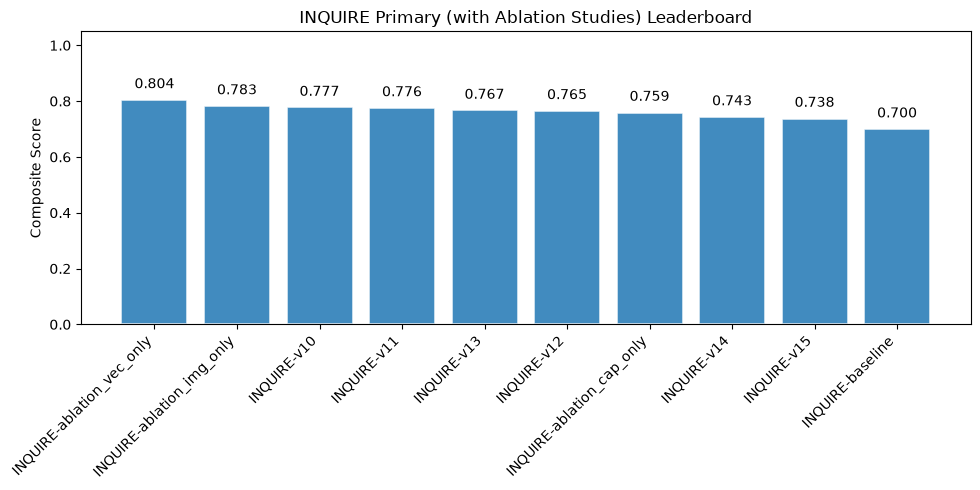

In [5]:
primary_ablation_df = render_single_benchmark_leaderboard(
    base_path=base_path,
    benchmark=current_benchmark,
    min_version=min_version,
    include_ablations=True,
    mode="primary",
    metric_weights=primary_metric_weights,
    display_fn=display,
)